In [23]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime as dt 
import matplotlib.pyplot as plt
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense

In [24]:
# Define the ticker symbol for the Shanghai Composite Index
ticker = '000001.SS'

# Define the date range for the full dAataset
start_date = '2014-01-01'
end_date = '2024-01-01'

# Download the full dataset
data = yf.download(ticker, start=start_date, end=end_date)

# Check for missing values and handle them
data = data.dropna()

print(pd.concat([data.head(1), data.tail(1)]))


[*********************100%%**********************]  1 of 1 completed

                   Open         High          Low        Close    Adj Close  \
Date                                                                          
2014-01-02  2112.125977  2113.110107  2101.016113  2109.386963  2109.386963   
2023-12-29  2950.836914  2975.031982  2950.017090  2974.935059  2974.935059   

            Volume  
Date                
2014-01-02   68500  
2023-12-29  290700  


In [25]:
# Extract close price as our target data, denoted by X
X = data.Close

# Perform the Augmented Dickey-Fuller (ADF) test to check if the time series is stationary
result = adfuller(X)
# Print the test statistic - a more negative value indicates a higher likelihood of stationarity
print('Dickey-Fuller Statistic: %f' % result[0])
# Print the p-value - a lower value (typically < 0.05) means we can reject the null hypothesis of non-stationarity
print('p-value: %f' % result[1])
# Print the critical values at different confidence levels (1%, 5%, and 10%) - the thresholds for the test statistic
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

# Perform the Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test to check if the time series is stationary
result_kpss = kpss(X, regression='c')
# Print the KPSS test statistic - a higher value indicates a higher likelihood of non-stationarity
print('KPSS Statistic: %f' % result_kpss[0])
# Print the p-value - a higher value (typically > 0.05) means we cannot reject the null hypothesis of stationarity
print('p-value: %f' % result_kpss[1])
# Print the critical values at different confidence levels (10%, 5%, 2.5%, and 1%) - the thresholds for the test statistic
print('Critical Values:')
for key, value in result_kpss[3].items():
    print('\t%s: %.3f' % (key, value))

Adata Statistic: -9.738395
p-value: 0.000000
Critical Values:
	1%: -3.433
	5%: -2.863
	10%: -2.567
KPSS Statistic: 0.101244
p-value: 0.100000
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739


c:\Users\p0f3h\anaconda3\envs\2024project\lib\site-packages\statsmodels\tsa\stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(


In [26]:
# Define a function for train-test split
def train_test_split(X, size=0.9):
    train = X[:int(X.shape[0]*size)]
    test = X[int(X.shape[0]*size):]
    return train, test

# Split train set and test set
train, test = train_test_split(X=data['Close'], size=0.9)

In [27]:
# Train an ARIMA model using the auto_arima function on the training data
arima_model = auto_arima(train, trace=True, error_action='ignore', suppress_warnings=True)

# Print a summary of the fitted ARIMA model
print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=22799.542, Time=1.40 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=22865.142, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=22858.123, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=22856.954, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=22863.357, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=22855.182, Time=0.31 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=22854.259, Time=0.37 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=22779.514, Time=1.68 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=22850.379, Time=0.64 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=22781.262, Time=1.23 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=1.66 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=22861.508, Time=1.18 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=22839.624, Time=0.40 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=22783.030, Time=1.58 sec
 ARIMA(3,1,2)(0,0,0)[0]  

In [28]:
# Extract residuals from ARIMA model
arima_residuals = arima_model.resid()

# LSTM model on ARIMA residuals
lstm_data = arima_residuals.values.reshape(-1, 1)  # Get residuals and reshape

# Normalize the data
sc = MinMaxScaler(feature_range=(0, 1))
sc_data = sc.fit_transform(lstm_data)

seq_len = 2  # Time step length t-2, t-1 ---> t
# Convert to the format required by the LSTM network (samples, time steps, features)
X_train = np.array([sc_data[i : i + seq_len, :] for i in range(sc_data.shape[0] - seq_len)])
y_train = np.array([sc_data[i + seq_len, :] for i in range(sc_data.shape[0] - seq_len)])

print(X_train.shape, y_train.shape)

(2185, 2, 1) (2185, 1)


In [29]:
# LSTM network using Keras
model = Sequential()
model.add(LSTM(units=64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
model.add(Dropout(0.2))  # Dropout layer
model.add(Dense(1))  # Fully connected layer
model.compile(loss='mean_squared_error', optimizer='adam')
# Train the model for 100 epochs with batch size of 32
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=2)

Epoch 1/100
69/69 - 3s - loss: 0.0025 - 3s/epoch - 44ms/step
Epoch 2/100
69/69 - 0s - loss: 4.2935e-04 - 329ms/epoch - 5ms/step
Epoch 3/100
69/69 - 0s - loss: 4.1686e-04 - 315ms/epoch - 5ms/step
Epoch 4/100
69/69 - 0s - loss: 4.1329e-04 - 321ms/epoch - 5ms/step
Epoch 5/100
69/69 - 0s - loss: 4.1379e-04 - 321ms/epoch - 5ms/step
Epoch 6/100
69/69 - 0s - loss: 3.9482e-04 - 313ms/epoch - 5ms/step
Epoch 7/100
69/69 - 0s - loss: 3.9486e-04 - 348ms/epoch - 5ms/step
Epoch 8/100
69/69 - 0s - loss: 3.9481e-04 - 324ms/epoch - 5ms/step
Epoch 9/100
69/69 - 0s - loss: 3.8804e-04 - 324ms/epoch - 5ms/step
Epoch 10/100
69/69 - 0s - loss: 3.8324e-04 - 331ms/epoch - 5ms/step
Epoch 11/100
69/69 - 0s - loss: 3.7251e-04 - 350ms/epoch - 5ms/step
Epoch 12/100
69/69 - 0s - loss: 3.7189e-04 - 319ms/epoch - 5ms/step
Epoch 13/100
69/69 - 0s - loss: 3.5728e-04 - 322ms/epoch - 5ms/step
Epoch 14/100
69/69 - 0s - loss: 3.6132e-04 - 328ms/epoch - 5ms/step
Epoch 15/100
69/69 - 0s - loss: 3.5484e-04 - 321ms/epoch - 5ms/

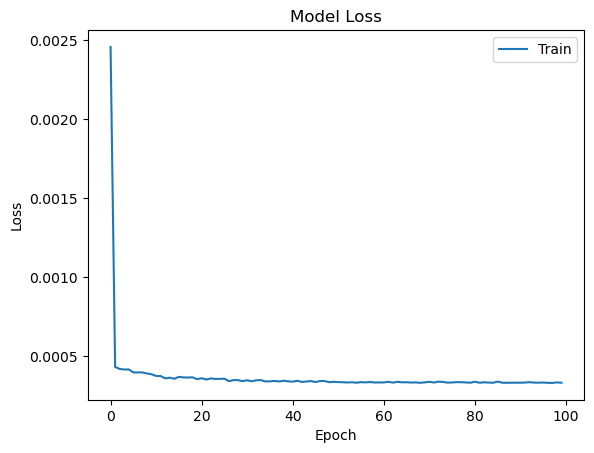

In [30]:
# Plot the training loss
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper right')
plt.show()

In [31]:
# Function to perform one-step forecast
def one_step_forecast():
    arima_forecast, conf_int = arima_model.predict(n_periods=1, return_conf_int=True)
    
    # Prepare the input for LSTM model from the last residuals
    last_residuals = arima_model.resid()[-seq_len:]
    
    # Check if last_residuals is a pandas Series or numpy array and convert accordingly
    if isinstance(last_residuals, pd.Series):
        last_residuals_np = last_residuals.values.reshape(1, seq_len, 1)
    else:
        last_residuals_np = last_residuals.reshape(1, seq_len, 1)

    last_residuals_scaled = sc.transform(last_residuals_np.reshape(-1, 1)).reshape(1, seq_len, 1)

    # Predict the next residual with LSTM model
    lstm_forecast_scaled = model.predict(last_residuals_scaled)[0, 0]
    lstm_forecast = sc.inverse_transform([[lstm_forecast_scaled]])[0, 0]
    
    return (
        arima_forecast.tolist()[0],
        np.asarray(conf_int).tolist()[0],
        lstm_forecast
    )

# Combine ARIMA and LSTM predictions on test data
arima_predictions = []
confidence_intervals = []
lstm_predictions = []

for x in test:
    arima_forecast, conf, lstm_forecast = one_step_forecast()
    arima_predictions.append(arima_forecast)
    confidence_intervals.append(conf)
    lstm_predictions.append(lstm_forecast)

    # Update the ARIMA model
    arima_model.update(x)
    arima_residuals = arima_model.resid()
    # LSTM model on ARIMA residuals
    lstm_data = arima_residuals.reshape(-1, 1)  # Get residuals and reshape
    
    # Normalize the data
    sc = MinMaxScaler(feature_range=(0, 1))
    sc_data = sc.fit_transform(lstm_data)
    
    seq_len = 2  # Time step length t-2, t-1 ---> t
    # Convert to the format required by the LSTM network (samples, time steps, features)
    X_train = np.array([sc_data[i : i + seq_len, :] for i in range(sc_data.shape[0] - seq_len)])
    y_train = np.array([sc_data[i + seq_len, :] for i in range(sc_data.shape[0] - seq_len)])
    
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=2)


c:\Users\p0f3h\anaconda3\envs\2024project\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


1/1 [==============================] - 0s 496ms/step
Epoch 1/50
69/69 - 0s - loss: 3.3090e-04 - 247ms/epoch - 4ms/step
Epoch 2/50
69/69 - 0s - loss: 3.2934e-04 - 303ms/epoch - 4ms/step
Epoch 3/50
69/69 - 0s - loss: 3.2944e-04 - 329ms/epoch - 5ms/step
Epoch 4/50
69/69 - 0s - loss: 3.2991e-04 - 334ms/epoch - 5ms/step
Epoch 5/50
69/69 - 0s - loss: 3.2918e-04 - 331ms/epoch - 5ms/step
Epoch 6/50
69/69 - 0s - loss: 3.2914e-04 - 331ms/epoch - 5ms/step
Epoch 7/50
69/69 - 0s - loss: 3.3032e-04 - 338ms/epoch - 5ms/step
Epoch 8/50
69/69 - 0s - loss: 3.2987e-04 - 334ms/epoch - 5ms/step
Epoch 9/50
69/69 - 0s - loss: 3.2922e-04 - 330ms/epoch - 5ms/step
Epoch 10/50
69/69 - 0s - loss: 3.3299e-04 - 344ms/epoch - 5ms/step
Epoch 11/50
69/69 - 0s - loss: 3.3238e-04 - 338ms/epoch - 5ms/step
Epoch 12/50
69/69 - 0s - loss: 3.3031e-04 - 329ms/epoch - 5ms/step
Epoch 13/50
69/69 - 0s - loss: 3.2841e-04 - 339ms/epoch - 5ms/step
Epoch 14/50
69/69 - 0s - loss: 3.3022e-04 - 331ms/epoch - 5ms/step
Epoch 15/50
69/69 

MAE: 18.551431875421194
RMSE: 23.550831113462554
MAPE: 0.5835384577754813%


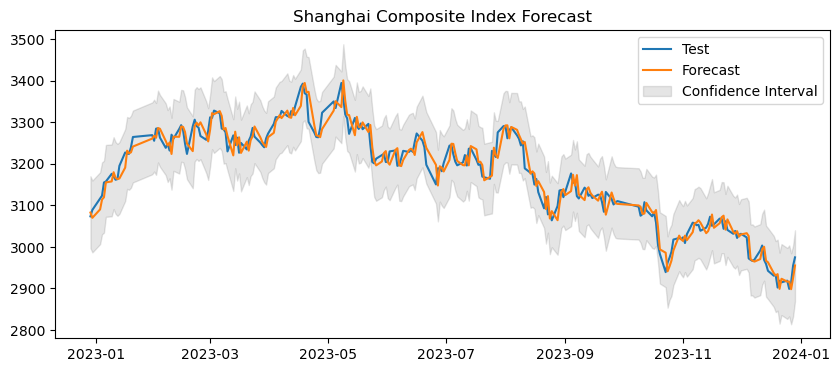

In [33]:
# Combine ARIMA and GARCH Forecasts
arima_forecast_series = pd.Series(arima_predictions, index=test.index)
conf_int_df = pd.DataFrame(confidence_intervals, index=test.index, columns=['lower', 'upper'])
lstm_forecast_series = pd.Series(lstm_predictions, index=test.index)

final_forecast = arima_forecast_series + lstm_forecast_series

# Evaluate the Forecast
mae = mean_absolute_error(test, final_forecast)
rmse = np.sqrt(mean_squared_error(test, final_forecast))
mape = np.mean(np.abs((test - final_forecast) / test)) * 100

# Print the evaluation metrics
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape}%')

# Plot the results
plt.figure(figsize=(10, 4))
plt.plot(test, label='Test')
plt.plot(final_forecast, label='Forecast')
plt.fill_between(conf_int_df.index, conf_int_df['lower'], conf_int_df['upper'], color='k', alpha=0.1, label='Confidence Interval')
plt.title('Shanghai Composite Index Forecast')
plt.legend()
plt.show()